In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import cv2

import tensorflow as tf
from glob import glob
from tqdm import tqdm

from PIL import Image

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kangggchan/eyes-openclose")

print("Path to dataset files:", path)

100%|██████████| 49.9M/49.9M [00:00<00:00, 152MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kangggchan/eyes-openclose/versions/1


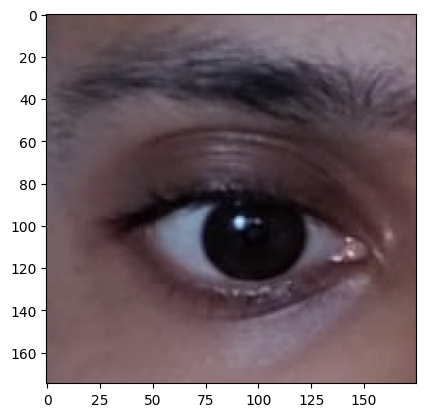

In [4]:
# import the image and normalize
img_array = cv2.imread(os.path.join(path, 'dataset', 'train', 'Open', '_0.jpg'))
plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))

In [5]:
img_size=128

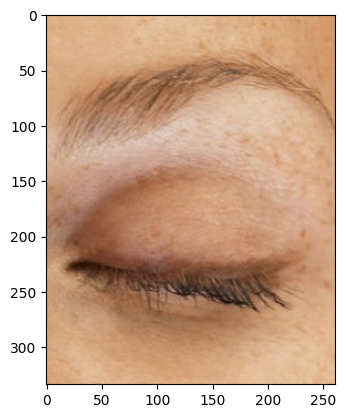

In [6]:
import os

Datadirectory = os.path.join(path, 'dataset', 'train')
Classes = ['Closed', 'Open']
for category in Classes:
    category_dir = os.path.join(Datadirectory, category)
    for img in os.listdir(category_dir):
        img_array = cv2.imread(os.path.join(category_dir, img), cv2.IMREAD_COLOR)
        plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
        plt.show()
        break
    break

In [7]:
training_data = []

def create_training_data():
    for category in Classes:
        path = os.path.join(Datadirectory, category)
        class_num = Classes.index(category)
        for img in os.listdir(path):
            try :
                img_array = cv2.imread(os.path.join(path,img), cv2.IMREAD_COLOR)
                backtorgb = cv2.cvtColor(img_array,cv2.COLOR_BGR2GRAY)
                new_array = cv2.resize(backtorgb, (img_size, img_size))
                training_data.append([new_array, class_num])
            except Exception as e:
                pass



In [8]:
create_training_data()
print(len(training_data))

1234


In [9]:
X=[]
Y=[]
for features, label in tqdm (training_data):
    X.append(features)
    Y.append(label)
X=np.array(X).reshape(-1,img_size,img_size,1)

100%|██████████| 1234/1234 [00:00<00:00, 1245972.83it/s]


In [10]:
X=X/255

In [11]:
X.shape

(1234, 128, 128, 1)

In [12]:
from tensorflow.python.eager.context import temporarily_disable_optionals_in_gradients
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Split data into tarning and validation
x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.2,random_state=42)

datagen=ImageDataGenerator(
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest' )





train_generator = datagen.flow(x_train, y_train, batch_size=32)
validation_generator = datagen.flow(x_val, y_val, batch_size=32)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, BatchNormalization, MaxPooling2D,Dropout, Flatten

model_simple = Sequential([
    Input(shape=(img_size, img_size, 1)),

    Conv2D(filters = 32, kernel_size = 5, strides = 1, activation = 'relu'),
    MaxPooling2D(),
    Dropout(0.2),

    Conv2D(filters = 64, kernel_size = 5, strides = 1, activation = 'relu'),
    MaxPooling2D(),
    Dropout(0.2),

    Conv2D(filters = 32, kernel_size = 3, strides = 1, activation = 'relu'),
    MaxPooling2D(),
    Dropout(0.2),

    Conv2D(filters = 16, kernel_size = 3, strides = 1, activation = 'relu'),
    MaxPooling2D(),
    Dropout(0.2),

    Flatten(),

    Dense(units  = 128, activation = 'relu'),
    Dense(units = 1, activation = 'sigmoid')
])

In [14]:
model_simple.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])
model_simple.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 58, 58, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 27, 27, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        51,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,641 (494.69 KB)

 Trainable params: 126,641 (494.69 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
import tensorflow as tf

callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='SimpleModel.keras',
    save_weights_only=False,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose =1)

history = model_simple.fit(train_generator, epochs=20, validation_data=validation_generator, callbacks=callback)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5627 - loss: 0.6830
Epoch 1: val_loss improved from None to 0.49630, saving model to SimpleModel.keras

Epoch 1: finished saving model to SimpleModel.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.6555 - loss: 0.6174 - val_accuracy: 0.7287 - val_loss: 0.4963
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8096 - loss: 0.4569
Epoch 2: val_loss improved from 0.49630 to 0.38000, saving model to SimpleModel.keras

Epoch 2: finished saving model to SimpleModel.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8267 - loss: 0.4308 - val_accuracy: 0.8664 - val_loss: 0.3800
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9041 - loss: 0.3001
Epoch 3: val_loss improved from 0.38000 to 0.21331, saving model to SimpleModel.keras

Epoch 3: finished saving model to SimpleModel.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8845 - loss: 0.3120 - val_accuracy: 0.9433 - val_loss:

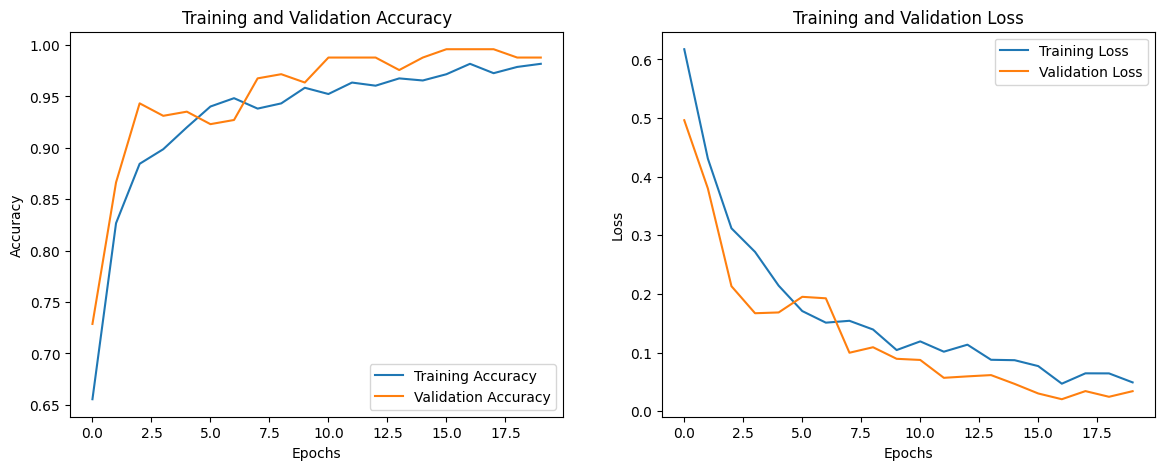

In [20]:
plt.figure(figsize=(14,5))
# training and Validation accuracy

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label="Training Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")
plt.legend()
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')



# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [18]:
# Evaluate and load the model performance
model_simple.evaluate(validation_generator)

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 312ms/step - accuracy: 0.9960 - loss: 0.0235


[0.023487770929932594, 0.9959514141082764]

In [22]:
from keras.models import load_model
best_model = load_model('SimpleModel.keras') # Changed path to reflect the saving location
best_model.evaluate(validation_generator) # Corrected typo: 'evalute' to 'evaluate' and 'validation_genrator' to 'validation_generator'

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 298ms/step - accuracy: 0.9919 - loss: 0.0305


[0.030495665967464447, 0.9919028282165527]

In [28]:
# Test the model with random image

# load saved model
model=tf.keras.models.load_model('SimpleModel.keras')

def predict_eye_state(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)

    # Check if image was loaded successfully
    if img is None:
        print(f"Error: Could not load image from {img_path}")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Ensure img_size is defined and accessible
    # (assuming img_size=128 is globally defined as in HVeF4psjylpt)
    img = cv2.resize(img, (img_size, img_size))

    img_array = np.expand_dims(img, axis=-1)  # Add channel dimension (H, W, 1)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension (1, H, W, 1)

    img_array = img_array / 255.0

    print(f"Shape of img_array before prediction: {img_array.shape}")
    prediction = model.predict(img_array)

    if prediction[0] > 0.5:
        print("The eye is open")
    else:
        print("The eye is closed")

In [29]:
# Test with a random image
predict_eye_state('/kaggle/input/eyes-openclose/dataset/test/Closed/_116.jpg')

Error: Could not load image from /kaggle/input/eyes-openclose/dataset/test/Closed/_116.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━

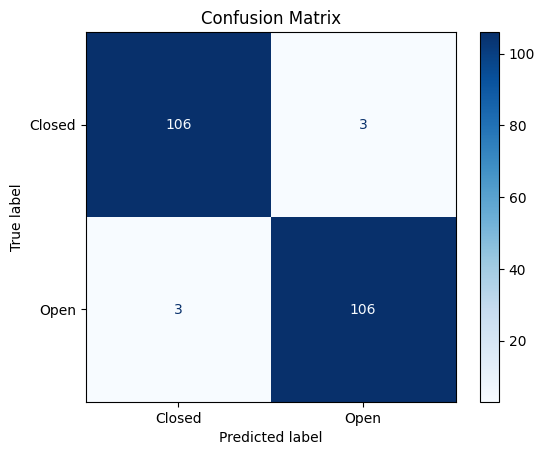

In [31]:
# Confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('SimpleModel.keras')

test_dir = os.path.join(path, 'dataset', 'test') # Corrected test directory path
classes = ['Closed', 'Open']

true_labels = []
predictions = []

for label, class_name in enumerate(classes):
    class_dir = os.path.join(test_dir, class_name)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)

        # Load image
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, (img_size, img_size))
        img_array = np.expand_dims(img, axis=-1)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0



          # Predict using the model
        prediction = model.predict(img_array)[0][0]
        predictions.append(1 if prediction > 0.5 else 0)

        # Add true label
        true_labels.append(label)

cm = confusion_matrix(true_labels, predictions, labels=[0, 1])

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/s

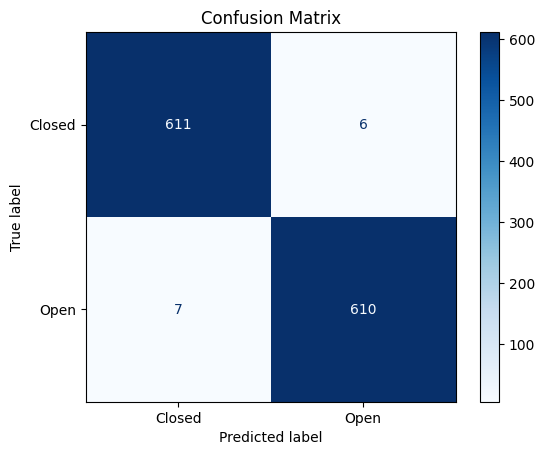

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('SimpleModel.keras')

test_dir = os.path.join(path, 'dataset', 'train') # Corrected path to use the downloaded dataset location
classes = ['Closed', 'Open']

true_labels = []
predictions = []

for label, class_name in enumerate(classes):
    class_dir = os.path.join(test_dir, class_name)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)

        # Load image
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, (img_size, img_size))
        img_array = np.expand_dims(img, axis=-1)

        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
        img_array = img_array / 255.0  # Normalize to [0, 1]

        # Predict using the model
        prediction = model.predict(img_array)[0][0]  # Get the prediction value
        predictions.append(1 if prediction > 0.5 else 0)  # Threshold at 0.5 for binary classification

        # Add true label
        true_labels.append(label)

cm = confusion_matrix(true_labels, predictions, labels=[0, 1])

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
